## 8 - Subplots & Layouts

### What are Subplots?
**Subplots** let you display multiple charts **side by side in a single figure**. This is useful when you want to compare related information without jumping between separate charts.

### Creating subplots with pyplot

**Method 1 - `plt.subplot(rows, cols, index)`**
```python
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)         # 1 row, 2 cols, chart 1
plt.plot(x, y1)
plt.title('Chart 1')

plt.subplot(1, 2, 2)         # 1 row, 2 cols, chart 2
plt.bar(x, y2)
plt.title('Chart 2')

plt.tight_layout()
plt.show()
```

**Method 2 - `plt.subplot2grid()` for custom sizes**
```python
plt.subplot2grid((3, 3), (0, 0), colspan=3)   # top row: full width
plt.subplot2grid((3, 3), (1, 0), colspan=2)   # middle left: 2 wide
plt.subplot2grid((3, 3), (1, 2), rowspan=2)   # right: 2 tall
```

### Spacing control
```python
plt.tight_layout()                         # auto-fix spacing
plt.tight_layout(pad=2.0)                  # extra padding
plt.subplots_adjust(hspace=0.4, wspace=0.3)  # manual control
```

### plt.suptitle() - overall title for the whole figure
```python
plt.suptitle('Overall Dashboard Title', fontsize=16, fontweight='bold')
```


In [1]:
import matplotlib.pyplot as plt

In [2]:
import numpy as np

rng = np.random.default_rng(1)
subjects  = ['Maths', 'Science', 'English', 'CompSci']
s_colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
all_data  = [rng.normal(65+i*2, 14, 50).clip(0,100) for i in range(4)]
cities    = ['Delhi', 'Mumbai', 'Pune', 'Bangalore', 'Hyderabad']
city_avg  = [68.4, 71.2, 65.8, 73.1, 69.5]
months    = ['Jan','Feb','Mar','Apr','May','Jun']
trend     = [63, 65, 68, 67, 71, 74]

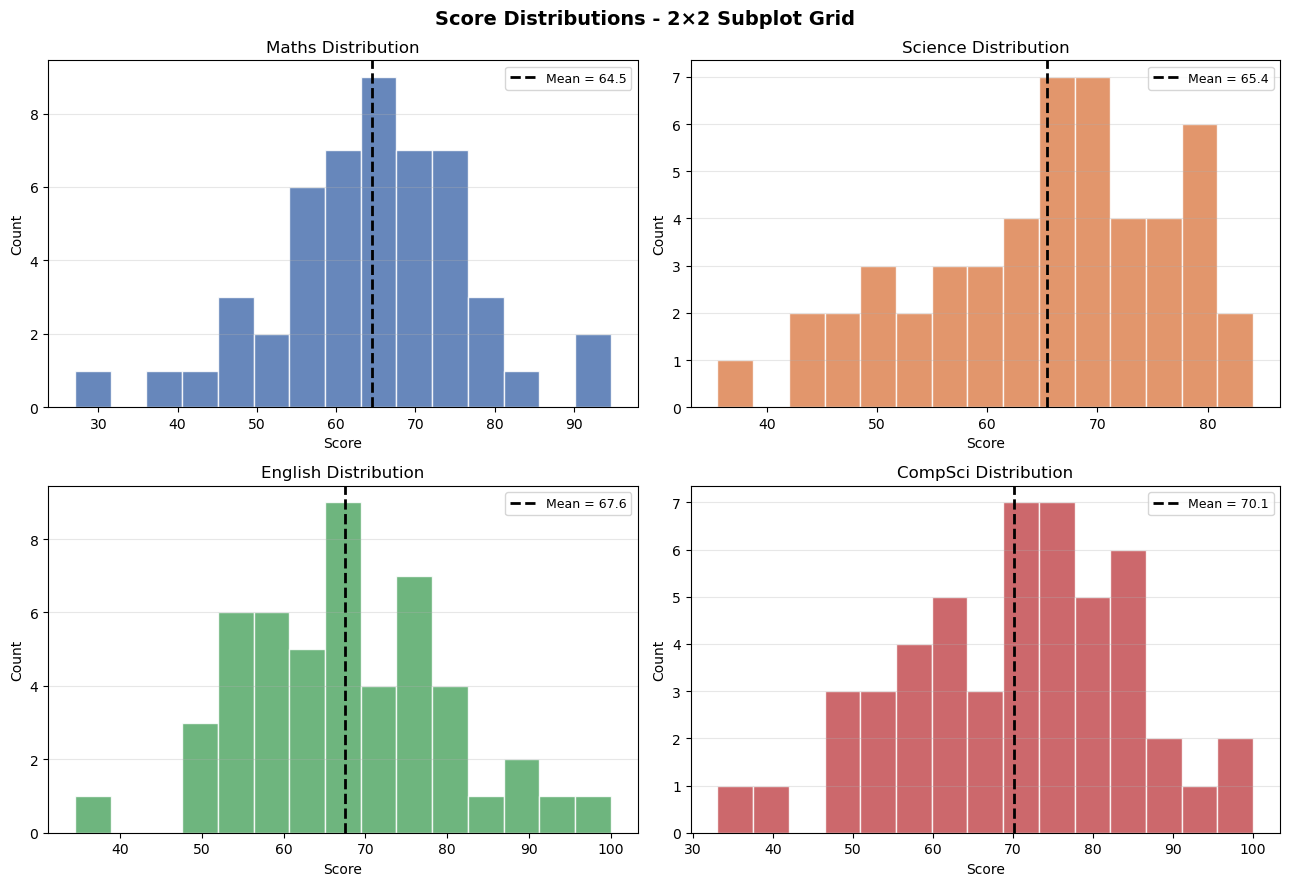

In [6]:
# Simple 2×2 grid
plt.figure(figsize=(13, 9))

for i, (subj, col, data) in enumerate(zip(subjects, s_colors, all_data)):
    plt.subplot(2, 2, i + 1)
    plt.hist(data, bins=15, color=col, edgecolor='white', alpha=0.85)
    plt.axvline(data.mean(), color='black', lw=2, ls='--',
                label=f'Mean = {data.mean():.1f}')
    
    plt.title(f'{subj} Distribution')
    plt.xlabel('Score')
    plt.ylabel('Count')
    
    plt.legend(fontsize=9)
    plt.grid(axis='y', alpha=0.3)

plt.suptitle('Score Distributions - 2×2 Subplot Grid', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

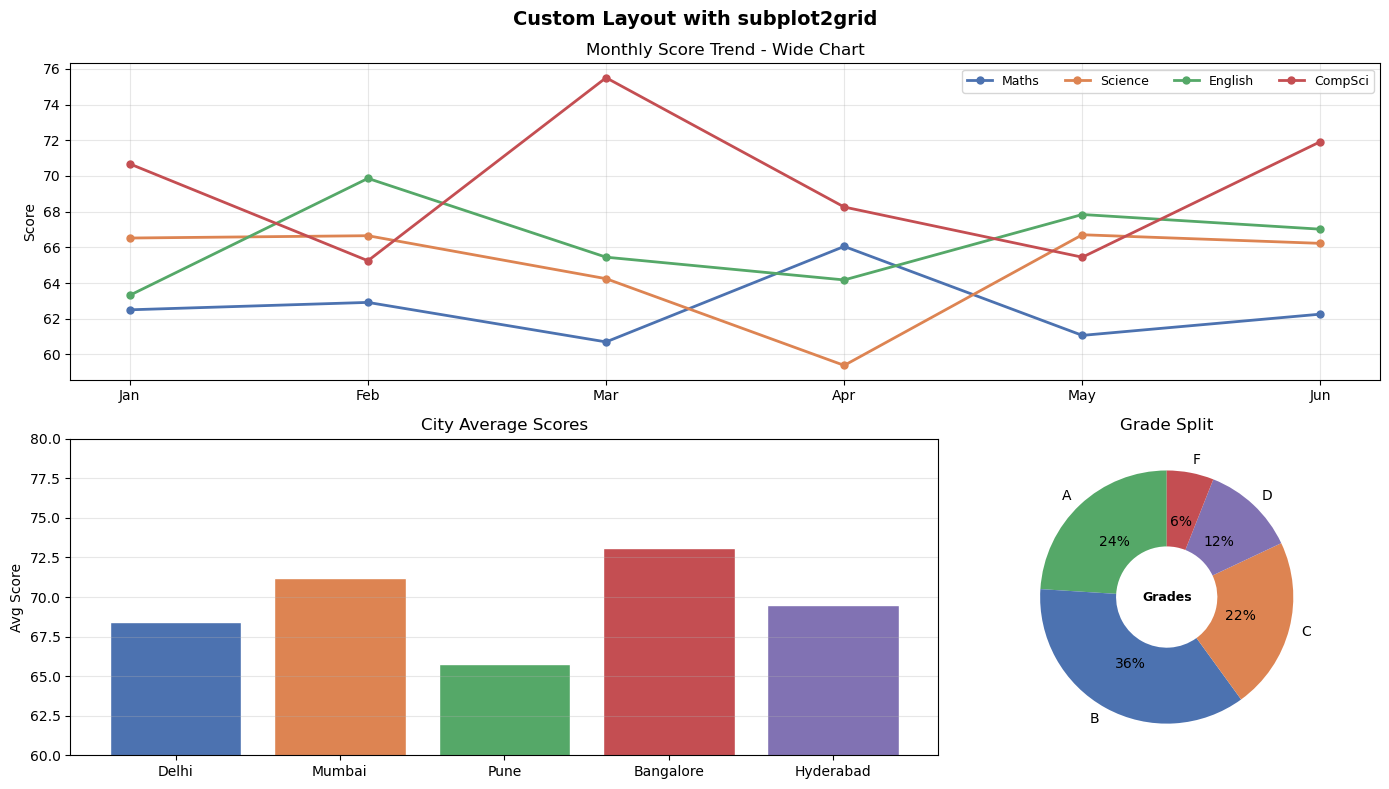

In [8]:
# Custom layout with subplot2grid
plt.figure(figsize=(14, 8))

# Top: wide line chart
plt.subplot2grid((2, 3), (0, 0), colspan=3)
for subj, col, data in zip(subjects, s_colors, all_data):
    monthly = [data.mean() + rng.normal(0, 3) for _ in months]
    plt.plot(months, monthly, color=col, lw=2, marker='o', ms=5, label=subj)
plt.title('Monthly Score Trend - Wide Chart')
plt.ylabel('Score')
plt.legend(ncol=4, fontsize=9)
plt.grid(True, alpha=0.3)

# Bottom left: bar chart
plt.subplot2grid((2, 3), (1, 0), colspan=2)
plt.bar(cities, city_avg,
        color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3'],
        edgecolor='white')
plt.title('City Average Scores')
plt.ylabel('Avg Score')
plt.ylim(60, 80)
plt.grid(axis='y', alpha=0.3)

# Bottom right: pie
plt.subplot2grid((2, 3), (1, 2))
plt.pie([12, 18, 11, 6, 3], labels=['A','B','C','D','F'],
        autopct='%1.0f%%',
        colors=['#55A868','#4C72B0','#DD8452','#8172B3','#C44E52'],
        startangle=90, wedgeprops=dict(width=0.6))
plt.text(0, 0, 'Grades', ha='center', va='center', fontsize=9, fontweight='bold')
plt.title('Grade Split')

plt.suptitle('Custom Layout with subplot2grid', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()